In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import random
from itertools import combinations

def build_wikidata_network(file_path):
    # 1. Load data and drop missing values
    df = pd.read_csv(file_path)
    df = df.dropna(subset=['page_name', 'thread_subject', 'username'])
    
    # 2. Create context ID based on page name and thread subject
    df['context_id'] = df['page_name'].astype(str) + " | " + df['thread_subject'].astype(str)
    
    # 3. Group users by context
    grouped_users = df.groupby('context_id')['username'].apply(set).tolist()
    
    # 4. Generate edges for users in the same context
    edges = []
    for users in grouped_users:
        if len(users) > 1:
            edges.extend(list(combinations(users, 2)))
            
    # 5. Build the graph
    G = nx.Graph()
    G.add_edges_from(edges)
    
    print("Network Construction")
    print(f"Dataset: {file_path}")
    print(f"Number of nodes: {G.number_of_nodes()}")
    print(f"Number of edges: {G.number_of_edges()}")
    
    return G

# Run for small network
file_path = "BOT_REQUESTS.csv" 
G_small = build_wikidata_network(file_path)

Network Construction
Dataset: BOT_REQUESTS.csv
Number of nodes: 527
Number of edges: 2425


1. Empirical Network Metrics
Average Degree: 9.2030
LCC Node Ratio: 98.48%
Average Clustering Coefficient (C): 0.6887
LCC Average Shortest Path (L): 2.6027

2. Random Network (Null Model) Metrics
Random network probability (p): 0.0175
Random network C: 0.0141
Random network L: 3.0871


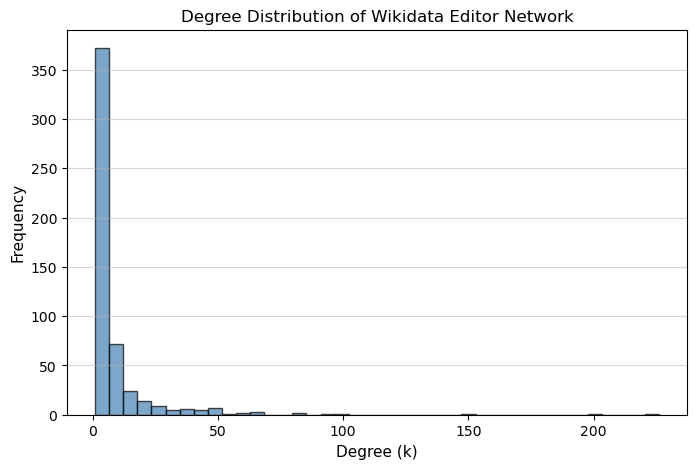

In [2]:
def analyze_network_metrics(G):
    print("1. Empirical Network Metrics")
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    
    # Calculate average degree
    degrees = [d for n, d in G.degree()]
    avg_degree = sum(degrees) / num_nodes
    print(f"Average Degree: {avg_degree:.4f}")
    
    # Extract Largest Connected Component (LCC)
    connected_components = sorted(nx.connected_components(G), key=len, reverse=True)
    LCC = G.subgraph(connected_components[0])
    print(f"LCC Node Ratio: {LCC.number_of_nodes() / num_nodes:.2%}")
    
    # Calculate core metrics
    C_real = nx.average_clustering(G)
    L_real = nx.average_shortest_path_length(LCC)
    print(f"Average Clustering Coefficient (C): {C_real:.4f}")
    print(f"LCC Average Shortest Path (L): {L_real:.4f}")
    
    print("\n2. Random Network (Null Model) Metrics")
    # Build ER random graph with same size
    p = (2 * num_edges) / (num_nodes * (num_nodes - 1))
    G_rand = nx.erdos_renyi_graph(num_nodes, p, seed=42) 
    
    # Extract LCC for the random graph
    rand_components = sorted(nx.connected_components(G_rand), key=len, reverse=True)
    LCC_rand = G_rand.subgraph(rand_components[0])
    
    C_rand = nx.average_clustering(G_rand)
    L_rand = nx.average_shortest_path_length(LCC_rand)
    
    print(f"Random network probability (p): {p:.4f}")
    print(f"Random network C: {C_rand:.4f}")
    print(f"Random network L: {L_rand:.4f}")
    
    # 3. Plot degree distribution
    plt.figure(figsize=(8, 5))
    plt.hist(degrees, bins=40, color='steelblue', edgecolor='black', alpha=0.7)
    plt.title("Degree Distribution of Wikidata Editor Network", fontsize=12)
    plt.xlabel("Degree (k)", fontsize=11)
    plt.ylabel("Frequency", fontsize=11)
    plt.grid(axis='y', alpha=0.5)
    plt.show()

# Run metrics for small network
analyze_network_metrics(G_small)

In [3]:
def simulate_epidemic_monitoring(G):
    print("Task C: Epidemic Monitoring Simulation")
    
    # 1. Randomly select 2 nodes from LCC
    LCC_nodes = max(nx.connected_components(G), key=len)
    G_LCC = G.subgraph(LCC_nodes)
    
    random.seed(42) 
    node_A, node_B = random.sample(list(G_LCC.nodes()), 2)
    print(f"Selected nodes for today: ['{node_A}', '{node_B}']\n")
    
    # 2. Evaluate isolation probability
    print("[Evaluation 1] Isolation probability:")
    shortest_path_len = nx.shortest_path_length(G_LCC, source=node_A, target=node_B)
    common_neighbors = list(nx.common_neighbors(G_LCC, node_A, node_B))
    
    print(f"Shortest path length between them: {shortest_path_len}")
    print(f"Number of common neighbors: {len(common_neighbors)}")
    
    if shortest_path_len > 3 and len(common_neighbors) == 0:
        print("Conclusion: Nodes are far apart and share no common neighbors. It is unlikely that the controversy has spread.")
    else:
        print("Conclusion: Nodes are close or share common neighbors. High risk of local controversy spread.")
        
    # 3. Priority list for target monitoring
    print("\n[Evaluation 2] Target node priority list (Top 5):")
    # Assume A and B are infected sources
    infected_seeds = {node_A, node_B}
    
    # Find susceptible neighbors
    susceptible_neighbors = set()
    for seed in infected_seeds:
        susceptible_neighbors.update(G_LCC.neighbors(seed))
    susceptible_neighbors.difference_update(infected_seeds) 
    
    # Sort logic
    priority_list = []
    for neighbor in susceptible_neighbors:
        exposure_edges = sum(1 for seed in infected_seeds if G_LCC.has_edge(neighbor, seed))
        degree = G_LCC.degree(neighbor)
        
        priority_list.append({
            'Node': neighbor, 
            'Exposure': exposure_edges, 
            'Degree': degree
        })
        
    # Sort by exposure and degree
    priority_list.sort(key=lambda x: (x['Exposure'], x['Degree']), reverse=True)
    
    if not priority_list:
        print("No susceptible neighbors found.")
    else:
        # Use pandas DataFrame for a clean, student-style output
        df_priority = pd.DataFrame(priority_list)
        print(df_priority.head(5).to_string(index=False))

# Run simulation for small network
simulate_epidemic_monitoring(G_small)

Task C: Epidemic Monitoring Simulation
Selected nodes for today: ['Nikki', 'Scarey1']

[Evaluation 1] Isolation probability:
Shortest path length between them: 3
Number of common neighbors: 0
Conclusion: Nodes are close or share common neighbors. High risk of local controversy spread.

[Evaluation 2] Target node priority list (Top 5):
          Node  Exposure  Degree
       Pasleim         1     226
         Jura1         1     198
Matěj Suchánek         1     152
      ValterVB         1      98
 Pigsonthewing         1      95


 Stage 1: Network Construction (PROJECT_CHAT.csv) 
Network Construction
Dataset: PROJECT_CHAT.csv
Number of nodes: 3941
Number of edges: 40255

 Stage 2: Metrics Analysis (PROJECT_CHAT.csv) 
1. Empirical Network Metrics
Average Degree: 20.4288
LCC Node Ratio: 99.57%
Average Clustering Coefficient (C): 0.7001
LCC Average Shortest Path (L): 2.7406

2. Random Network (Null Model) Metrics
Random network probability (p): 0.0052
Random network C: 0.0054
Random network L: 3.0227


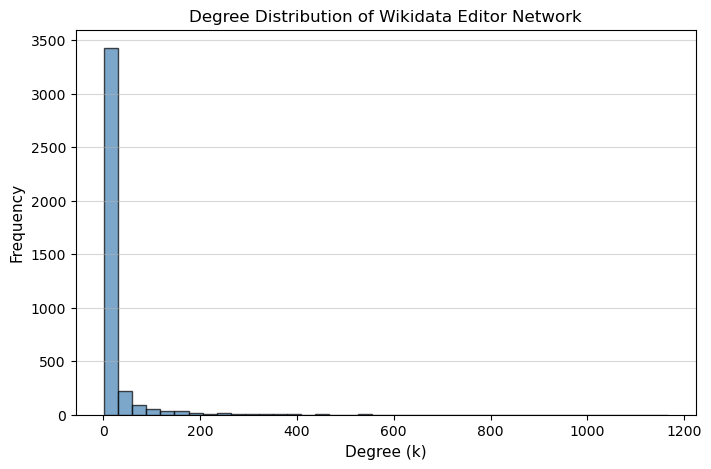


 Stage 3: Epidemic Monitoring (PROJECT_CHAT.csv) 
Task C: Epidemic Monitoring Simulation
Selected nodes for today: ['180.97.204.30', 'Mono']

[Evaluation 1] Isolation probability:
Shortest path length between them: 3
Number of common neighbors: 0
Conclusion: Nodes are close or share common neighbors. High risk of local controversy spread.

[Evaluation 2] Target node priority list (Top 5):
          Node  Exposure  Degree
Matěj Suchánek         1     733
Liuxinyu970226         1     378
        Vogone         1     203


In [4]:
dataset_medium = "PROJECT_CHAT.csv"

print(f" Stage 1: Network Construction ({dataset_medium}) ")
G_medium = build_wikidata_network(dataset_medium)

print(f"\n Stage 2: Metrics Analysis ({dataset_medium}) ")
analyze_network_metrics(G_medium)

print(f"\n Stage 3: Epidemic Monitoring ({dataset_medium}) ")
simulate_epidemic_monitoring(G_medium)

In [5]:
def safe_analyze_large_network(G, sample_size=100):
    print(" 1. Large Network Metrics (with sampling) ")
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    
    degrees = [d for n, d in G.degree()]
    avg_degree = sum(degrees) / num_nodes
    print(f"Average Degree: {avg_degree:.4f}")
    
    # Extract LCC
    connected_components = sorted(nx.connected_components(G), key=len, reverse=True)
    LCC = G.subgraph(connected_components[0])
    print(f"LCC Node Ratio: {LCC.number_of_nodes() / num_nodes:.2%}")
    
    print("Calculating clustering coefficient...")
    C_real = nx.average_clustering(G)
    print(f"Average Clustering Coefficient (C): {C_real:.4f}")
    
    print(f"Estimating shortest path with {sample_size} samples...")
    sample_nodes = random.sample(list(LCC.nodes()), min(sample_size, LCC.number_of_nodes()))
    total_path_length = 0
    total_paths = 0
    
    for source in sample_nodes:
        lengths = nx.single_source_shortest_path_length(LCC, source)
        total_path_length += sum(lengths.values())
        total_paths += len(lengths) - 1 
        
    L_real = total_path_length / total_paths if total_paths > 0 else 0
    print(f"Estimated LCC Shortest Path (L): {L_real:.4f}")
    
    print("\n 2. Random Network Expected Metrics ")
    p = (2 * num_edges) / (num_nodes * (num_nodes - 1))
    
    # For very large networks, L approx ln(N)/ln(<k>)
    L_rand_approx = np.log(num_nodes) / np.log(avg_degree) if avg_degree > 1 else 0
    print(f"Random network p: {p:.6f}")
    print(f"Expected random C (≈ p): {p:.6f}")
    print(f"Expected random L: {L_rand_approx:.4f}")

# Run for large network
dataset_large = "REQUEST_FOR_DELETION.csv"

print(f" Stage 1: Network Construction ({dataset_large}) ")
G_large = build_wikidata_network(dataset_large)

print(f"\n Stage 2: Metrics Analysis ({dataset_large}) ")
safe_analyze_large_network(G_large)

print(f"\n Stage 3: Epidemic Monitoring ({dataset_large}) ")
simulate_epidemic_monitoring(G_large)

 Stage 1: Network Construction (REQUEST_FOR_DELETION.csv) 
Network Construction
Dataset: REQUEST_FOR_DELETION.csv
Number of nodes: 9887
Number of edges: 33488

 Stage 2: Metrics Analysis (REQUEST_FOR_DELETION.csv) 
 1. Large Network Metrics (with sampling) 
Average Degree: 6.7741
LCC Node Ratio: 99.83%
Calculating clustering coefficient...
Average Clustering Coefficient (C): 0.3938
Estimating shortest path with 100 samples...
Estimated LCC Shortest Path (L): 2.7096

 2. Random Network Expected Metrics 
Random network p: 0.000685
Expected random C (≈ p): 0.000685
Expected random L: 4.8084

 Stage 3: Epidemic Monitoring (REQUEST_FOR_DELETION.csv) 
Task C: Epidemic Monitoring Simulation
Selected nodes for today: ['69.255.241.130', 'User 50']

[Evaluation 1] Isolation probability:
Shortest path length between them: 4
Number of common neighbors: 0
Conclusion: Nodes are far apart and share no common neighbors. It is unlikely that the controversy has spread.

[Evaluation 2] Target node priori